Using device: cuda
Classes   : {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Total rows: 10015
Train: 8012 | Test: 2003
Pre-loading TRAIN images...


100%|██████████| 8012/8012 [02:15<00:00, 58.94it/s]


Pre-loading TEST images...


100%|██████████| 2003/2003 [00:33<00:00, 60.32it/s]


Pre-load complete.
Val: 1602 | Test: 2003

MAIN TRAINING — majority_frac=0.8, rounds=20
✅ Client partitions verified.
Client sizes: [1352, 1482, 5178]
  Client 0: [209, 328, 88, 10, 89, 537, 91]
  Client 1: [27, 42, 703, 73, 89, 536, 12]
  Client 2: [26, 41, 88, 9, 712, 4291, 11]

RUNNING FEDAVG
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


  Round 1/20 fedavg → val F1: 0.4889
  Round 2/20 fedavg → val F1: 0.5833
  Round 3/20 fedavg → val F1: 0.6331
  Round 4/20 fedavg → val F1: 0.6413
  Round 5/20 fedavg → val F1: 0.6351
  Round 6/20 fedavg → val F1: 0.7276
  Round 7/20 fedavg → val F1: 0.7314
  Round 8/20 fedavg → val F1: 0.7565
  Round 9/20 fedavg → val F1: 0.7848
  Round 10/20 fedavg → val F1: 0.7749
  Round 11/20 fedavg → val F1: 0.7878
  Round 12/20 fedavg → val F1: 0.8233
  Round 13/20 fedavg → val F1: 0.7906
  Round 14/20 fedavg → val F1: 0.8178
  Round 15/20 fedavg → val F1: 0.8692
  Round 16/20 fedavg → val F1: 0.7687
  Round 17/20 fedavg → val F1: 0.8191
  Round 18/20 fedavg → val F1: 0.7943
  Round 19/20 fedavg → val F1: 0.8495
  Round 20/20 fedavg → val F1: 0.8292
✅ fedavg → Test Acc=0.8038  F1=0.6534  ECE=0.1158

RUNNING WEIGHTED_FEDAVG
  Round 1/20 weighted_fedavg → val F1: 0.4304
  Round 2/20 weighted_fedavg → val F1: 0.4401
  Round 3/20 weighted_fedavg → val F1: 0.4946
  Round 4/20 weighted_fedavg → val F

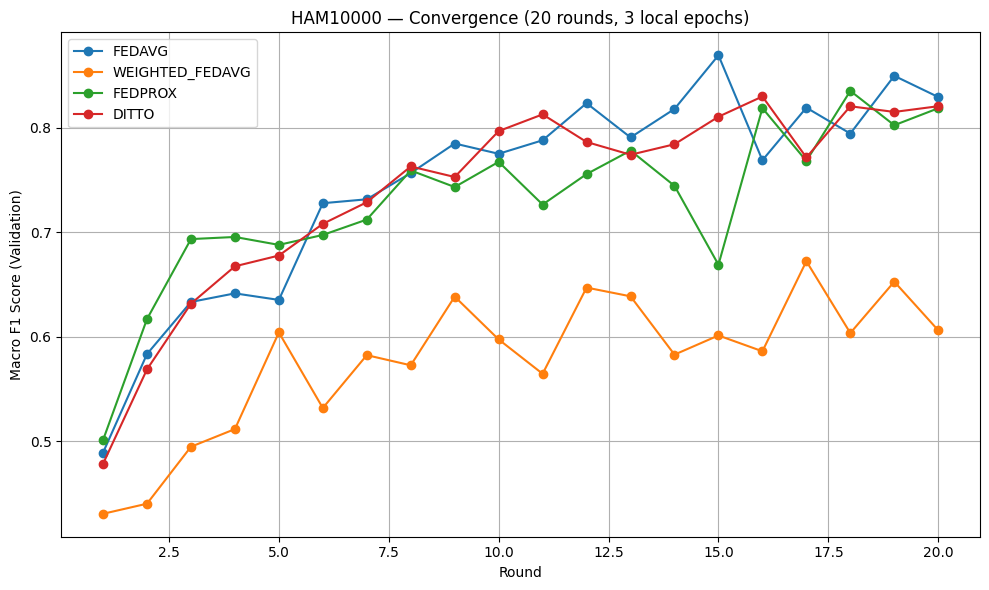

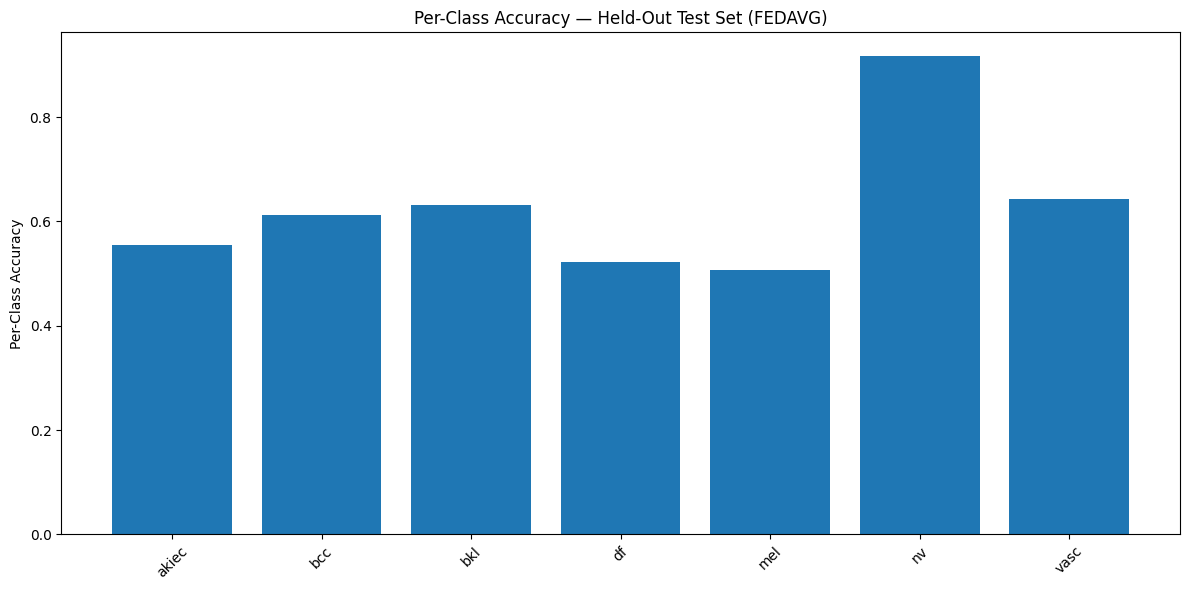


✅ Training complete.
Saved: fl_results_all_methods.csv, ablation_results.csv
       test_df.csv, meta.json
       final_model_*.pth, client_*_*.pth
       convergence_all_methods.png, per_class_accuracy.png


In [1]:
# ==========================================
# CELL 1: HAM10000 TRAINING
# Main training (majority_frac=0.8, 20 rounds)
# + Non-IID Severity Ablation (frac=0.5, 0.7, 10 rounds each)
# Methods: FedAvg, Weighted FedAvg, FedProx, Ditto
# Fix: CalibrationError task argument for torchmetrics >= 0.11
# ==========================================

!pip install -q kagglehub scikit-learn seaborn torchmetrics tqdm

import os, copy, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, balanced_accuracy_score
)
import matplotlib.pyplot as plt
from PIL import Image
from torchmetrics import CalibrationError
from collections import OrderedDict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. DATASET DOWNLOAD & LOADING
# ==========================================
import kagglehub
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

df   = pd.read_csv(os.path.join(path, "HAM10000_metadata.csv"))
img1 = os.path.join(path, "HAM10000_images_part_1")
img2 = os.path.join(path, "HAM10000_images_part_2")

label_map   = {l: i for i, l in enumerate(sorted(df['dx'].unique()))}
df['label'] = df['dx'].map(label_map)
num_classes = len(label_map)
class_names = list(label_map.keys())
print(f"Classes   : {label_map}")
print(f"Total rows: {len(df)}")

# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

# ==========================================
# 3. PRE-LOAD IMAGES INTO RAM
# ==========================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

def load_image(img_id):
    p1 = os.path.join(img1, img_id + ".jpg")
    p2 = os.path.join(img2, img_id + ".jpg")
    try:
        return transform(
            Image.open(p1 if os.path.exists(p1) else p2).convert("RGB")
        )
    except Exception:
        return torch.zeros(3, 224, 224)

print("Pre-loading TRAIN images...")
train_tensors = [load_image(r['image_id'])
                 for _, r in tqdm(train_df.iterrows(), total=len(train_df))]
train_labels  = train_df['label'].tolist()

print("Pre-loading TEST images...")
test_tensors = [load_image(r['image_id'])
                for _, r in tqdm(test_df.iterrows(), total=len(test_df))]
test_labels  = test_df['label'].tolist()
print("Pre-load complete.")

# ==========================================
# 4. DATASET CLASS
# ==========================================
class InMemoryDataset(Dataset):
    def __init__(self, images, labels, noise_level=0.0):
        self.images      = images
        self.labels      = labels
        self.noise_level = noise_level

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].clone()
        if self.noise_level > 0:
            img += torch.randn_like(img) * self.noise_level / 255.0
            img  = torch.clamp(img, 0, 1)
        return img, self.labels[idx]

test_dataset = InMemoryDataset(test_tensors, test_labels)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

val_idx    = np.random.RandomState(42).choice(
                 len(train_tensors), int(0.2 * len(train_tensors)),
                 replace=False)
val_imgs   = [train_tensors[i] for i in val_idx]
val_lbls   = [train_labels[i]  for i in val_idx]
val_loader = DataLoader(InMemoryDataset(val_imgs, val_lbls),
                        batch_size=32, shuffle=False,
                        num_workers=2, pin_memory=True)
print(f"Val: {len(val_idx)} | Test: {len(test_dataset)}")

# ==========================================
# 5. DISJOINT NON-IID SPLIT
# ==========================================
majority_classes_per_client = [[0, 1], [2, 3], [4, 5]]

def disjoint_non_iid_split(labels, majority_classes_per_client,
                            majority_frac=0.8, seed=42):
    np.random.seed(seed)
    labels_arr = np.array(labels)
    n_clients  = len(majority_classes_per_client)
    assigned   = np.full(len(labels), -1, dtype=int)

    for class_id in range(num_classes):
        pos = np.where(labels_arr == class_id)[0].tolist()
        np.random.shuffle(pos)
        owner = next(
            (c for c, cls_list in enumerate(majority_classes_per_client)
             if class_id in cls_list), 0
        )
        n_maj   = int(len(pos) * majority_frac)
        maj_pos = pos[:n_maj]
        oth_pos = pos[n_maj:]
        for i in maj_pos: assigned[i] = owner
        others = [c for c in range(n_clients) if c != owner]
        for c, chunk in zip(others,
                            np.array_split(oth_pos, max(len(others), 1))):
            for i in chunk: assigned[i] = c

    assigned[assigned == -1] = 0

    for ci in range(n_clients):
        for cj in range(ci + 1, n_clients):
            pi = set(np.where(assigned == ci)[0].tolist())
            pj = set(np.where(assigned == cj)[0].tolist())
            assert pi.isdisjoint(pj), \
                f"ERROR: Client {ci} and {cj} share samples!"
    assert (assigned >= 0).all()

    return [np.where(assigned == c)[0].tolist()
            for c in range(n_clients)]

# ==========================================
# 6. DATALOADER BUILDER
# ==========================================
def build_dataloaders(client_indices,
                      noise_levels=[0.0, 20.0, 10.0],
                      batch_size=32):
    loaders = []
    for cid, idx in enumerate(client_indices):
        imgs    = [train_tensors[i] for i in idx]
        lbls    = [train_labels[i]  for i in idx]
        ds      = InMemoryDataset(imgs, lbls, noise_levels[cid])
        counts  = np.bincount(lbls, minlength=num_classes)
        sw      = 1.0 / counts[lbls]; sw /= sw.sum()
        sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
        loaders.append(DataLoader(ds, batch_size=batch_size,
                                  sampler=sampler,
                                  num_workers=2, pin_memory=True))
    return loaders

# ==========================================
# 7. CLASS WEIGHTS
# ==========================================
class_counts      = np.bincount(train_labels, minlength=num_classes)
class_weights_raw = 1.0 / class_counts
class_weights_t   = torch.tensor(
    class_weights_raw / class_weights_raw.sum(),
    dtype=torch.float32
).to(device)

# ==========================================
# 8. MODEL
# ==========================================
def get_model():
    m    = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)

# ==========================================
# 9. METRICS
# FIX: CalibrationError now uses task='multiclass'
#      with manual fallback for any version
# ==========================================
def compute_ece(y_prob, y_true, n_bins=15):
    """Works on any torchmetrics version."""
    try:
        calib = CalibrationError(
            task='multiclass',
            num_classes=num_classes,
            n_bins=n_bins,
            norm='l1'
        )
        return calib(
            torch.tensor(y_prob),
            torch.tensor(y_true)
        ).item()
    except Exception:
        # Manual ECE fallback
        probs_t       = torch.tensor(y_prob)
        labels_t      = torch.tensor(y_true)
        confidences, predictions = probs_t.max(dim=1)
        accuracies    = predictions.eq(labels_t)
        bin_edges     = torch.linspace(0, 1, n_bins + 1)
        ece           = 0.0
        for i in range(n_bins):
            mask = (confidences > bin_edges[i]) & \
                   (confidences <= bin_edges[i + 1])
            if mask.sum() > 0:
                bin_acc  = accuracies[mask].float().mean().item()
                bin_conf = confidences[mask].mean().item()
                ece     += mask.sum().item() * abs(bin_acc - bin_conf)
        return ece / max(len(y_true), 1)


def compute_all_metrics(y_true, y_pred, y_prob=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    per_class_prec, per_class_rec, per_class_acc = [], [], []
    for c in range(num_classes):
        tp    = np.sum((y_pred == c) & (y_true == c))
        fp    = np.sum((y_pred == c) & (y_true != c))
        fn    = np.sum((y_pred != c) & (y_true == c))
        prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        acc_c = np.mean(y_pred[y_true == c] == c) \
                if np.sum(y_true == c) > 0 else 0.0
        per_class_prec.append(prec)
        per_class_rec.append(rec)
        per_class_acc.append(acc_c)

    metrics = {
        'accuracy':            accuracy_score(y_true, y_pred),
        'balanced_accuracy':   balanced_accuracy_score(y_true, y_pred),
        'f1_macro':            f1_score(y_true, y_pred, average='macro',
                                        zero_division=0),
        'f1_weighted':         f1_score(y_true, y_pred, average='weighted',
                                        zero_division=0),
        'precision_macro':     precision_score(y_true, y_pred,
                                               average='macro',
                                               zero_division=0),
        'recall_macro':        recall_score(y_true, y_pred,
                                            average='macro',
                                            zero_division=0),
        'per_class_precision': per_class_prec,
        'per_class_recall':    per_class_rec,
        'per_class_accuracy':  per_class_acc,
        'g_mean': np.exp(
            np.mean(np.log([r + 1e-8 for r in per_class_rec]))
        ),
        'ece': compute_ece(y_prob, y_true.tolist()) \
               if y_prob is not None else None,
    }
    return metrics


def evaluate_model(model, dataloader, return_probs=False):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in dataloader:
            x     = x.to(device)
            probs = F.softmax(model(x), dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
            all_probs.extend(probs.cpu().numpy())
    return compute_all_metrics(
        all_labels, all_preds,
        all_probs if return_probs else None
    )

# ==========================================
# 10. LOCAL TRAINING
# ==========================================
MU = 0.001

def train_local(model, loader, global_state_dict,
                local_epochs=3, lr=1e-4,
                mu=0.0, ditto_lambda=0.0):
    model.train()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)

    for _ in range(local_epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)

            if mu > 0:
                prox = sum(
                    torch.sum((p - global_state_dict[n].to(device)) ** 2)
                    for n, p in model.named_parameters()
                    if n in global_state_dict
                    and p.dtype.is_floating_point
                )
                loss += (mu / 2) * prox

            if ditto_lambda > 0:
                ditto = sum(
                    torch.sum((p - global_state_dict[n].to(device)) ** 2)
                    for n, p in model.named_parameters()
                    if n in global_state_dict
                    and p.dtype.is_floating_point
                )
                loss += ditto_lambda * ditto

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

    return {k: v.cpu().clone() for k, v in model.state_dict().items()}

# ==========================================
# 11. AGGREGATION FUNCTIONS
# ==========================================
def fedavg_aggregate(local_weights):
    avg = OrderedDict()
    for key in local_weights[0]:
        tensors = [w[key] for w in local_weights]
        avg[key] = torch.stack(tensors).mean(dim=0) \
                   if tensors[0].dtype.is_floating_point \
                   else tensors[0].clone()
    return avg


def weighted_fedavg_aggregate(local_weights, client_sizes):
    total = sum(client_sizes)
    avg   = OrderedDict()
    for key in local_weights[0]:
        tensors = [w[key] for w in local_weights]
        if tensors[0].dtype.is_floating_point:
            avg[key] = sum(w[key] * (s / total)
                           for w, s in zip(local_weights, client_sizes))
        else:
            avg[key] = tensors[0].clone()
    return avg


def fedprox_aggregate(local_weights, global_weights, mu=MU):
    avg = fedavg_aggregate(local_weights)
    for key in avg:
        if avg[key].dtype.is_floating_point:
            avg[key] = avg[key] - mu * (
                avg[key] - global_weights[key].cpu()
            )
    return avg

# ==========================================
# 12. GENERIC FL RUNNER
# ==========================================
def run_fl_method(name, dataloaders, client_sizes,
                  rounds=20, local_epochs=3, lr=1e-4,
                  save_clients=False, tag=''):
    global_model     = get_model()
    global_weights   = {k: v.cpu()
                        for k, v in global_model.state_dict().items()}
    client_models    = [get_model() for _ in range(3)]
    personal_weights = [
        {k: v.cpu().clone()
         for k, v in global_model.state_dict().items()}
        for _ in range(3)
    ]
    best_f1, best_state = -1.0, None
    history = []

    for rnd in range(rounds):

        if name == 'ditto':
            # Step A — clean FedAvg for global (no Ditto penalty)
            global_local = []
            for cid, loader in enumerate(dataloaders):
                tmp = get_model()
                tmp.load_state_dict(global_weights, strict=True)
                w = train_local(tmp, loader, global_weights,
                                local_epochs=local_epochs, lr=lr)
                global_local.append(w)
            global_weights = fedavg_aggregate(global_local)
            global_model.load_state_dict(global_weights, strict=True)

            # Step B — personal update with Ditto penalty
            for cid, loader in enumerate(dataloaders):
                client_models[cid].load_state_dict(
                    personal_weights[cid], strict=True)
                pw = train_local(
                    client_models[cid], loader, global_weights,
                    local_epochs=local_epochs, lr=lr,
                    ditto_lambda=0.005
                )
                personal_weights[cid] = pw

        else:
            local_weights = []
            for cid, loader in enumerate(dataloaders):
                client_models[cid].load_state_dict(
                    global_weights, strict=True)
                w = train_local(
                    client_models[cid], loader, global_weights,
                    local_epochs=local_epochs, lr=lr,
                    mu=(MU if name == 'fedprox' else 0.0)
                )
                local_weights.append(w)

            if name == 'fedavg':
                global_weights = fedavg_aggregate(local_weights)
            elif name == 'weighted_fedavg':
                global_weights = weighted_fedavg_aggregate(
                    local_weights, client_sizes)
            elif name == 'fedprox':
                global_weights = fedprox_aggregate(
                    local_weights, global_weights, mu=MU)
            global_model.load_state_dict(global_weights, strict=True)

        val_m = evaluate_model(global_model, val_loader)
        history.append({
            'round':        rnd,
            'aggregation':  name,
            'f1_macro':     val_m['f1_macro'],
            'accuracy':     val_m['accuracy'],
            'balanced_acc': val_m['balanced_accuracy'],
            'g_mean':       val_m['g_mean'],
        })
        print(f"  Round {rnd+1}/{rounds} {name} → "
              f"val F1: {val_m['f1_macro']:.4f}")

        if val_m['f1_macro'] > best_f1:
            best_f1    = val_m['f1_macro']
            best_state = copy.deepcopy(global_weights)

    global_model.load_state_dict(best_state, strict=True)

    if save_clients:
        for cid in range(3):
            if name == 'ditto':
                cm = get_model()
                cm.load_state_dict(personal_weights[cid], strict=True)
            else:
                cm = client_models[cid]
            torch.save(cm.state_dict(),
                       f"/kaggle/working/{tag}client_{name}_{cid}.pth")

    final_m = evaluate_model(global_model, test_loader, return_probs=True)
    return history, global_model, client_models, final_m

# ==========================================
# 13. GRAD-CAM & IoU
# ==========================================
def grad_cam(model, img_tensor, target_class, target_layer='layer4'):
    model.eval()
    img_t = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
    grads, acts = [], []
    def bwd(m, gi, go): grads.append(go[0])
    def fwd(m, i, o):   acts.append(o)
    tm = dict(model.named_modules()).get(target_layer)
    h1 = tm.register_forward_hook(fwd)
    h2 = tm.register_backward_hook(bwd)
    out = model(img_t)
    out[0, target_class].backward()
    h1.remove(); h2.remove()
    grad    = grads[0].cpu().detach().numpy()[0]
    act     = acts[0].cpu().detach().numpy()[0]
    weights = np.mean(grad, axis=(1, 2))
    cam     = np.maximum(
        np.sum([w * a for w, a in zip(weights, act)], axis=0), 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam


def compute_iou(m1, m2, threshold=0.5):
    b1    = (m1 > threshold).astype(np.uint8)
    b2    = (m2 > threshold).astype(np.uint8)
    inter = np.logical_and(b1, b2).sum()
    union = np.logical_or(b1,  b2).sum()
    return (inter / union) if union > 0 else (1.0 if inter == 0 else 0.0)


def compute_avg_iou(global_model, client_models, dataset,
                    n_samples=50, threshold=0.5):
    np.random.seed(42)
    indices  = np.random.choice(len(dataset), n_samples, replace=False)
    all_ious = [[] for _ in client_models]
    for idx in indices:
        img, label = dataset[idx]
        g_cam = grad_cam(global_model, img.to(device), label)
        for cid, cm in enumerate(client_models):
            c_cam = grad_cam(cm, img.to(device), label)
            all_ious[cid].append(compute_iou(g_cam, c_cam, threshold))
    per_client = [float(np.mean(v)) for v in all_ious]
    return float(np.mean(per_client)), per_client

# ==========================================
# 14. MAIN TRAINING RUN (majority_frac=0.8)
# ==========================================
MAIN_FRAC    = 0.8
ROUNDS       = 20
LOCAL_EPOCHS = 3
LR           = 1e-4

print(f"\n{'='*60}")
print(f"MAIN TRAINING — majority_frac={MAIN_FRAC}, rounds={ROUNDS}")
print(f"{'='*60}")

client_indices = disjoint_non_iid_split(
    train_labels, majority_classes_per_client,
    majority_frac=MAIN_FRAC
)
client_sizes = [len(idx) for idx in client_indices]
dataloaders  = build_dataloaders(client_indices)

print(f"✅ Client partitions verified.")
print(f"Client sizes: {client_sizes}")
for i, idx in enumerate(client_indices):
    cl = [train_labels[j] for j in idx]
    print(f"  Client {i}: {np.bincount(cl, minlength=num_classes).tolist()}")

method_names = ['fedavg', 'weighted_fedavg', 'fedprox', 'ditto']

all_history        = []
final_models       = {}
client_models_dict = {}
final_metrics_dict = {}

for name in method_names:
    print(f"\n{'='*55}\nRUNNING {name.upper()}\n{'='*55}")
    hist, gmodel, cmodels, fmetrics = run_fl_method(
        name, dataloaders, client_sizes,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, lr=LR,
        save_clients=True, tag=''
    )
    for rec in hist:
        all_history.append(rec)

    final_models[name]       = gmodel
    client_models_dict[name] = cmodels
    final_metrics_dict[name] = fmetrics

    torch.save(gmodel.state_dict(),
               f"/kaggle/working/final_model_{name}.pth")
    print(f"✅ {name} → "
          f"Test Acc={fmetrics['accuracy']:.4f}  "
          f"F1={fmetrics['f1_macro']:.4f}  "
          f"ECE={fmetrics['ece']:.4f}")

# ==========================================
# 15. NON-IID SEVERITY ABLATION
# frac=0.5 and frac=0.7, 10 rounds each
# ==========================================
ABLATION_ROUNDS = 10
ABLATION_FRACS  = [0.5, 0.7]

print(f"\n{'='*60}")
print(f"NON-IID SEVERITY ABLATION")
print(f"Fracs: {ABLATION_FRACS}, Rounds: {ABLATION_ROUNDS}")
print(f"{'='*60}")

ablation_results = []

# Include main run in ablation table
for name in method_names:
    m = final_metrics_dict[name]
    ablation_results.append({
        'majority_frac': MAIN_FRAC,
        'method':        name,
        'accuracy':      m['accuracy'],
        'f1_macro':      m['f1_macro'],
        'g_mean':        m['g_mean'],
        'balanced_acc':  m['balanced_accuracy'],
    })

for frac in ABLATION_FRACS:
    print(f"\n--- Ablation: majority_frac={frac} ---")

    abl_indices = disjoint_non_iid_split(
        train_labels, majority_classes_per_client,
        majority_frac=frac
    )
    abl_sizes   = [len(idx) for idx in abl_indices]
    abl_loaders = build_dataloaders(abl_indices)
    print(f"Client sizes: {abl_sizes}")

    for name in method_names:
        print(f"\n  {name.upper()} (frac={frac})")
        _, gmodel, _, fmetrics = run_fl_method(
            name, abl_loaders, abl_sizes,
            rounds=ABLATION_ROUNDS,
            local_epochs=LOCAL_EPOCHS,
            lr=LR,
            save_clients=False,
            tag=f'abl{int(frac*10)}_'
        )
        ablation_results.append({
            'majority_frac': frac,
            'method':        name,
            'accuracy':      fmetrics['accuracy'],
            'f1_macro':      fmetrics['f1_macro'],
            'g_mean':        fmetrics['g_mean'],
            'balanced_acc':  fmetrics['balanced_accuracy'],
        })
        print(f"  ✅ frac={frac} {name} → "
              f"F1={fmetrics['f1_macro']:.4f}")

# ==========================================
# 16. SAVE ALL ARTIFACTS
# ==========================================
pd.DataFrame(all_history).to_csv(
    "/kaggle/working/fl_results_all_methods.csv", index=False)

pd.DataFrame(ablation_results).to_csv(
    "/kaggle/working/ablation_results.csv", index=False)

test_df.to_csv("/kaggle/working/test_df.csv", index=False)

with open("/kaggle/working/meta.json", "w") as f:
    json.dump({
        'label_map':                   label_map,
        'class_names':                 class_names,
        'majority_classes_per_client': majority_classes_per_client,
        'client_sizes':                client_sizes,
    }, f)

print("\n✅ All artifacts saved.")

# ==========================================
# 17. CONVERGENCE PLOT
# ==========================================
df_hist = pd.DataFrame(all_history)
plt.figure(figsize=(10, 6))
for name in method_names:
    sub = df_hist[df_hist['aggregation'] == name]
    plt.plot(sub['round'] + 1, sub['f1_macro'],
             marker='o', label=name.upper())
plt.xlabel('Round')
plt.ylabel('Macro F1 Score (Validation)')
plt.title(f'HAM10000 — Convergence '
          f'({ROUNDS} rounds, {LOCAL_EPOCHS} local epochs)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("/kaggle/working/convergence_all_methods.png", dpi=150)
plt.show()

# Per-class accuracy for best method on test set
best_name    = max(final_metrics_dict,
                   key=lambda x: final_metrics_dict[x]['f1_macro'])
best_metrics = final_metrics_dict[best_name]

plt.figure(figsize=(12, 6))
plt.bar(range(num_classes), best_metrics['per_class_accuracy'],
        tick_label=class_names)
plt.xticks(rotation=45)
plt.ylabel('Per-Class Accuracy')
plt.title(f'Per-Class Accuracy — Held-Out Test Set ({best_name.upper()})')
plt.tight_layout()
plt.savefig("/kaggle/working/per_class_accuracy.png", dpi=150)
plt.show()

print("\n✅ Training complete.")
print("Saved: fl_results_all_methods.csv, ablation_results.csv")
print("       test_df.csv, meta.json")
print("       final_model_*.pth, client_*_*.pth")
print("       convergence_all_methods.png, per_class_accuracy.png")

Using device: cuda
Test set: 2003 samples
Pre-loading test images...


100%|██████████| 2003/2003 [00:18<00:00, 110.74it/s]


✅ Loaded fedavg
✅ Loaded weighted_fedavg
✅ Loaded fedprox
✅ Loaded ditto

Building centralized baseline...
Pre-loading centralized train images...


100%|██████████| 8012/8012 [01:11<00:00, 112.80it/s]


Centralized → Acc=0.8178  F1=0.7188

Training local-only models...


  C0 local → Acc=0.7464  F1=0.5397


  C1 local → Acc=0.7119  F1=0.4384


  C2 local → Acc=0.7464  F1=0.4149

Computing Grad-CAM IoU (50 images per method)...
  fedavg: avg=0.5245  per-client=['0.550', '0.501', '0.522']
  weighted_fedavg: avg=0.4572  per-client=['0.464', '0.382', '0.526']
  fedprox: avg=0.5137  per-client=['0.600', '0.440', '0.501']
  ditto: avg=0.5621  per-client=['0.605', '0.539', '0.542']

===== FINAL TEST METRICS =====
Method                   Acc     F1      G-mean    BalAcc    IoU     
----------------------------------------------------------------------
Centralized              0.8178  0.7188  0.7082    0.7163    N/A
Best Local (C0)          0.7464  0.5397  0.4400    0.5952    N/A
fedavg                   0.8038  0.6534  0.6152    0.6264    0.5245
weighted_fedavg          0.7474  0.4811  0.3541    0.4503    0.4572
fedprox                  0.7978  0.6280  0.5696    0.6101    0.5137
ditto                    0.7938  0.6433  0.6185    0.6381    0.5621

✅ Best FL improvement over local: 21.1%

Grad-CAM for: fedavg


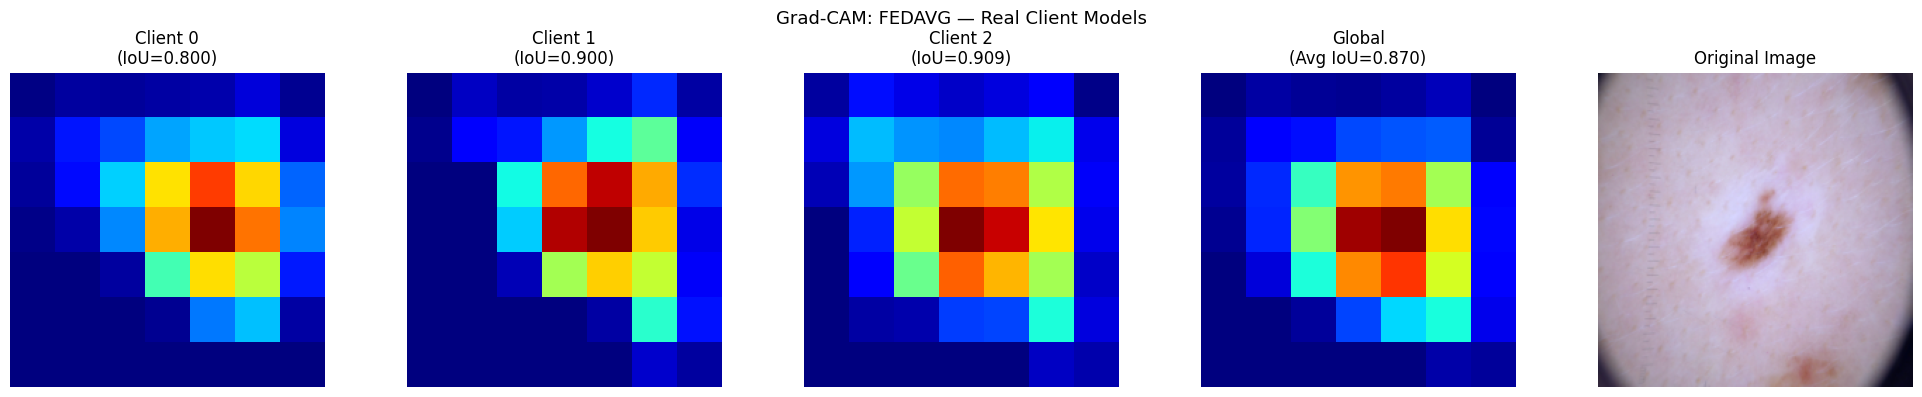

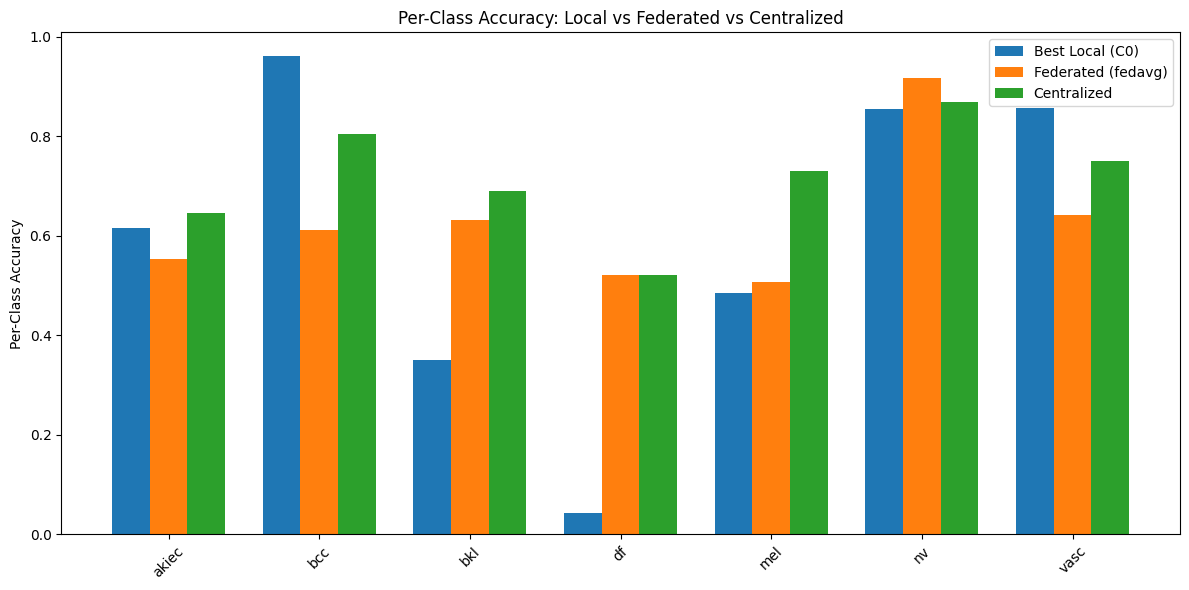

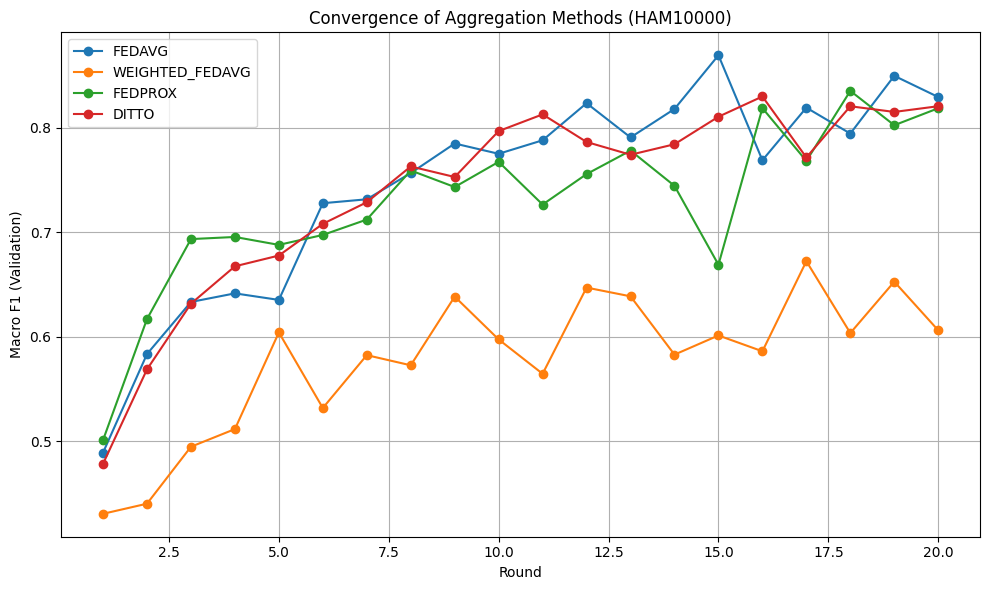


Generating confusion matrices...


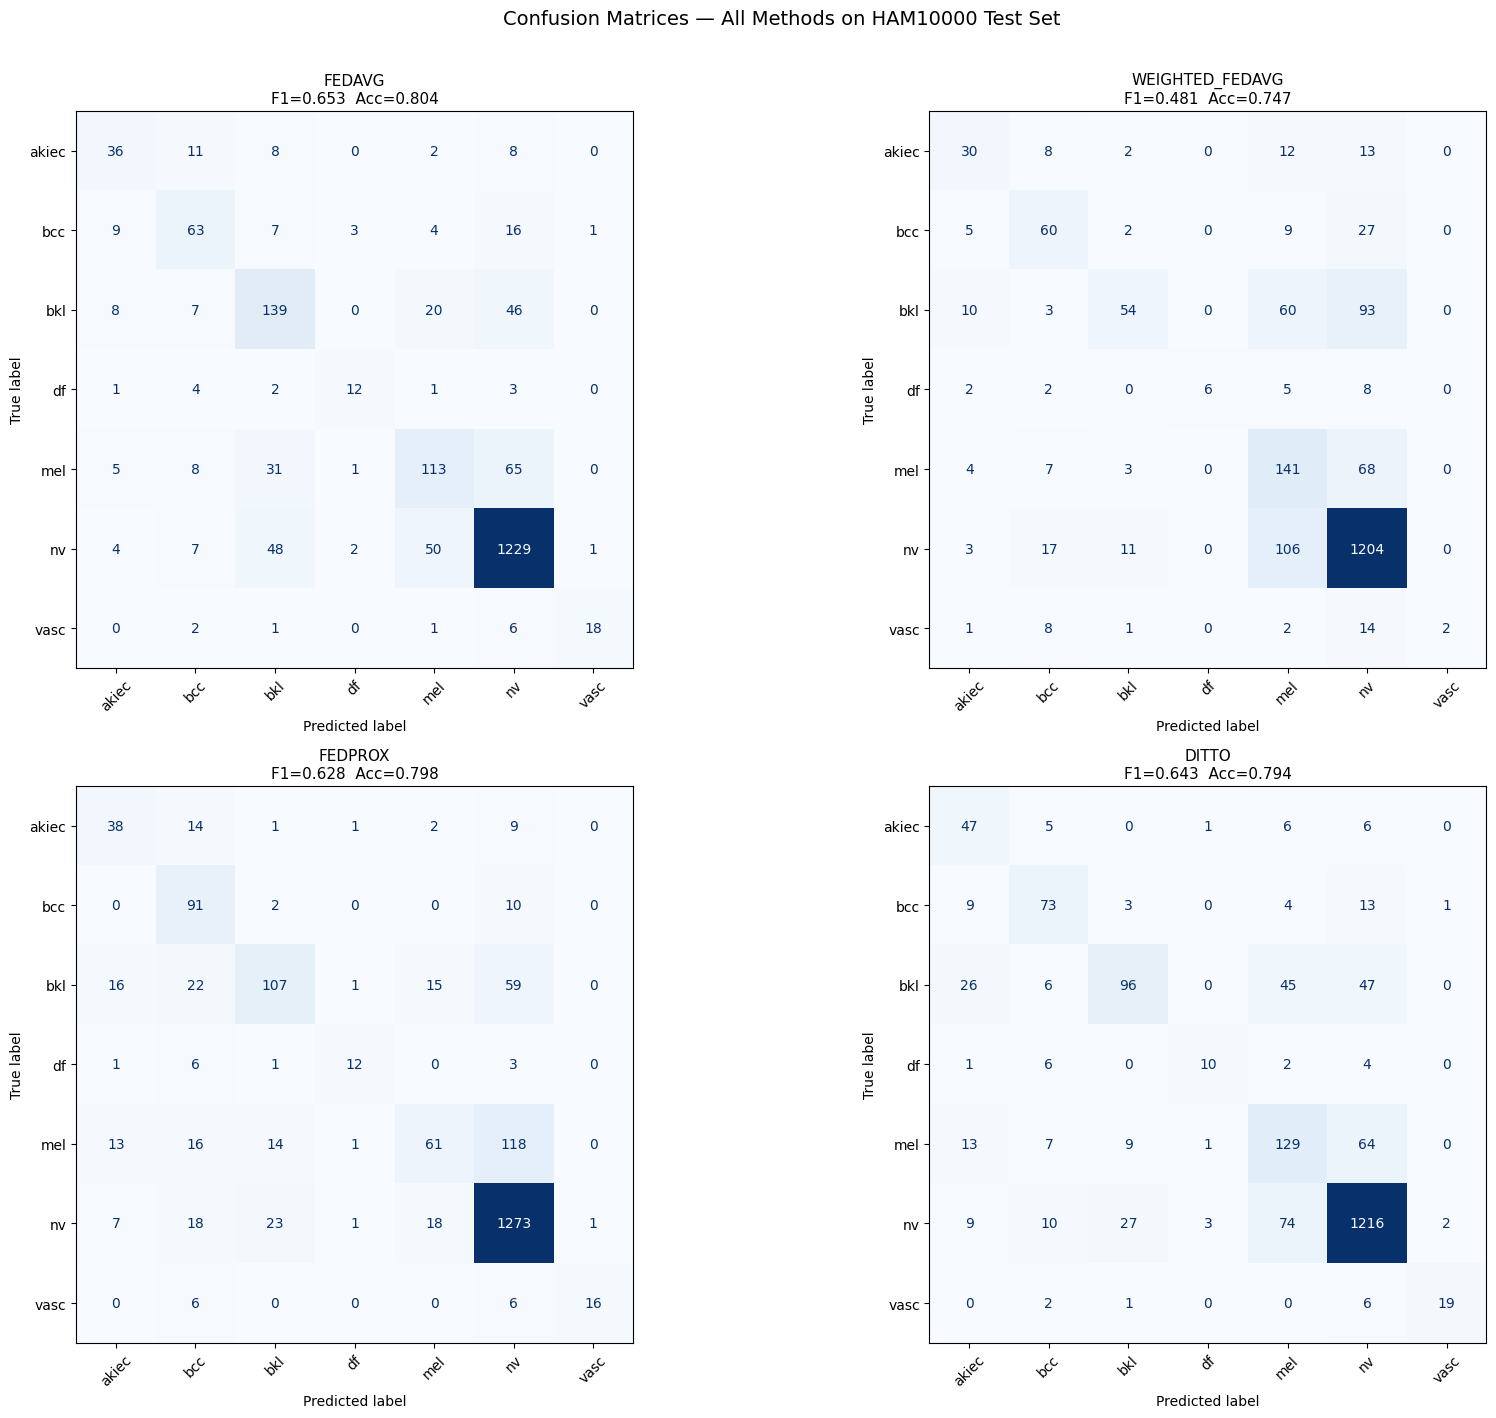

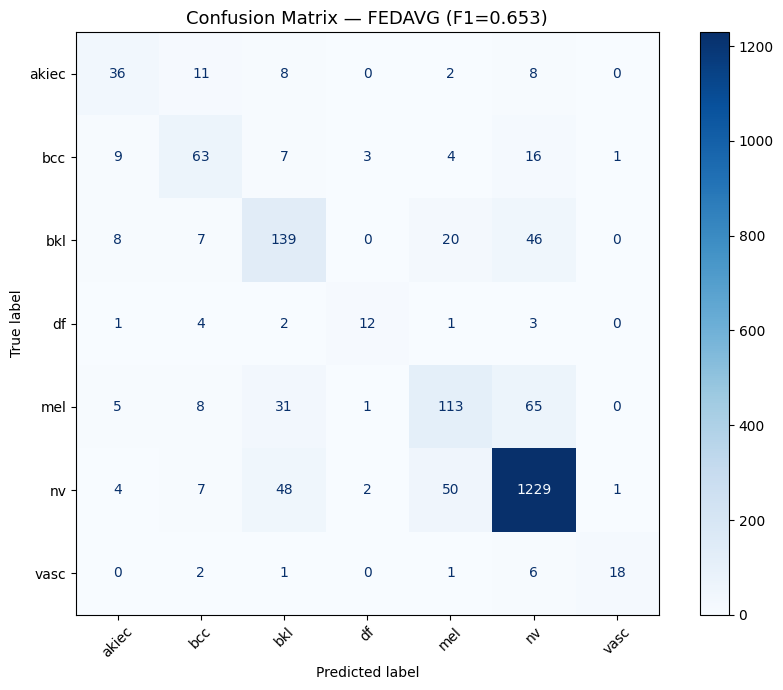

✅ Confusion matrices saved.

Computing communication cost...
  fedavg              : 268.3 MB/round, 5.37 GB total (20 rounds)
  weighted_fedavg     : 268.3 MB/round, 5.37 GB total (20 rounds)
  fedprox             : 268.3 MB/round, 5.37 GB total (20 rounds)
  ditto               : 536.6 MB/round, 10.73 GB total (20 rounds)

Communication Cost Table:
         Method Parameters Per_Round_MB Total_20R_GB                 Note
         fedavg 11,180,103     268.3 MB      5.37 GB             standard
weighted_fedavg 11,180,103     268.3 MB      5.37 GB             standard
        fedprox 11,180,103     268.3 MB      5.37 GB             standard
          ditto 11,180,103     536.6 MB     10.73 GB 2× (global+personal)


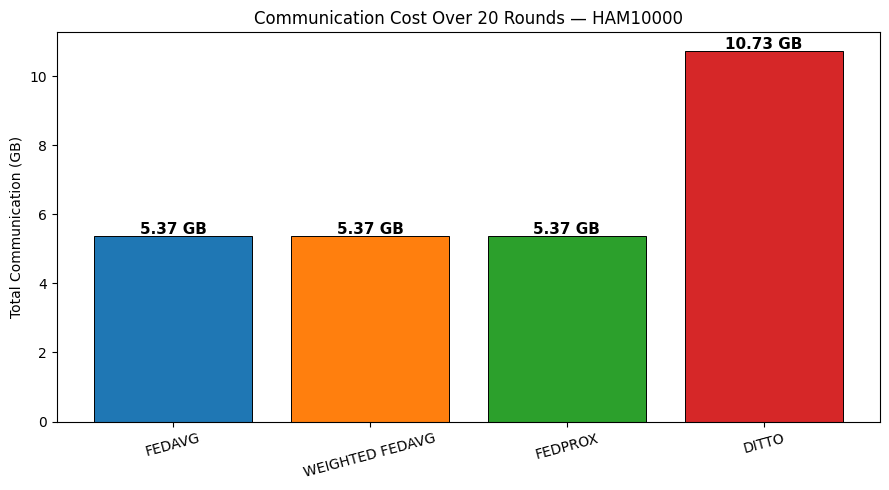

✅ Communication cost saved.

Generating F1 gain per class chart...


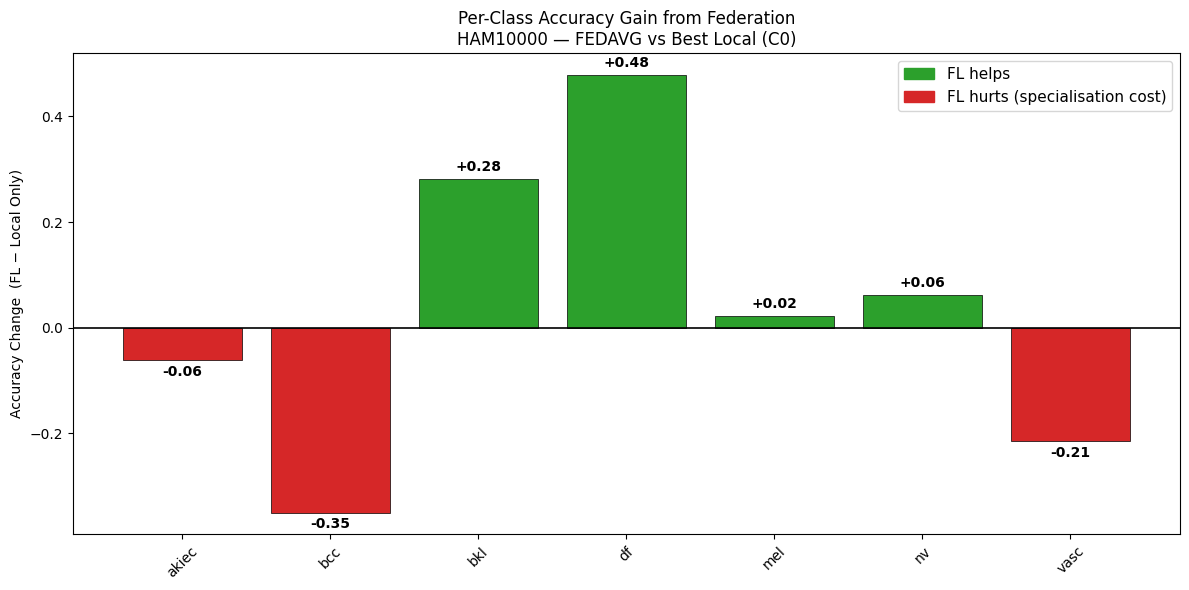

✅ F1 gain chart saved.

Generating radar chart...


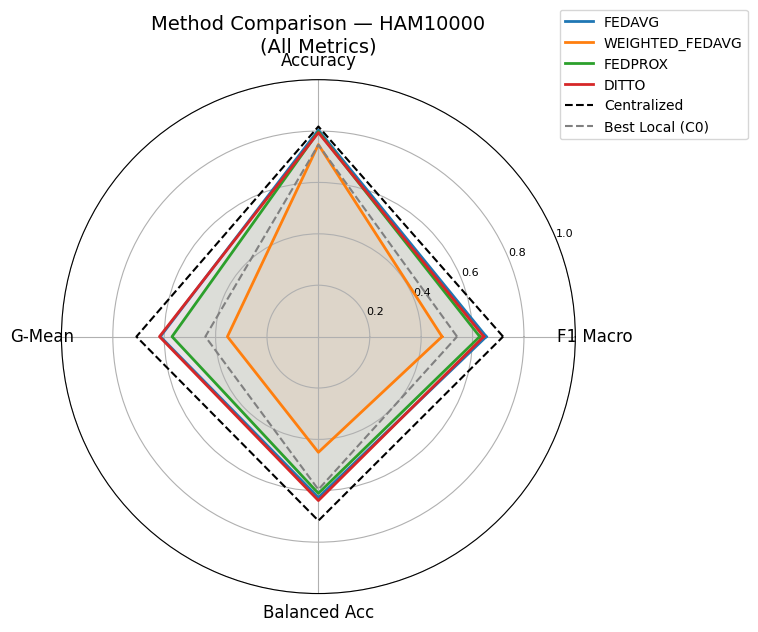

✅ Radar chart saved.

Generating ablation severity plot...


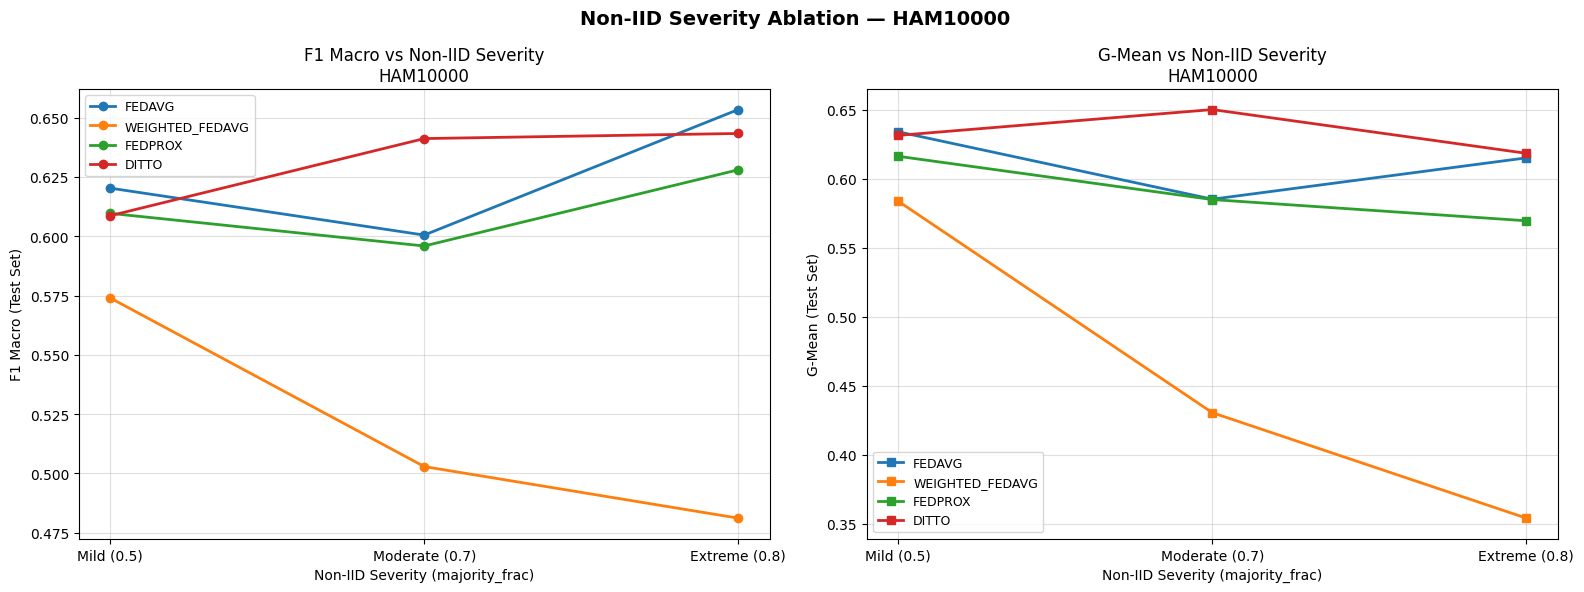


Ablation Summary Table:
majority_frac       0.5     0.7     0.8
method                                 
ditto            0.6086  0.6412  0.6433
fedavg           0.6203  0.6005  0.6534
fedprox          0.6096  0.5959  0.6280
weighted_fedavg  0.5740  0.5029  0.4811
✅ Ablation plots saved.

ALL OUTPUTS SAVED:
  ✅ final_comparison_table_corrected.csv
  ✅ convergence_clean.png
  ✅ per_class_comparison_corrected.png
  ✅ gradcam_real_clients.png
  ✅ confusion_matrices_all.png
  ✅ confusion_matrix_best.png
  ✅ communication_cost.csv
  ✅ communication_cost.png
  ✅ fl_gain_per_class.png
  ✅ radar_chart.png
  ✅ ablation_severity.png
  ✅ ablation_pivot.csv


In [2]:
# ==========================================
# CELL 2: HAM10000 VALIDATION — FULL SUITE
# Includes: comparison table, Grad-CAM IoU,
#   confusion matrices, communication cost,
#   F1 gain chart, radar chart, ablation plot
# ==========================================

import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. RELOAD ASSETS
# ==========================================
import kagglehub
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
img1 = os.path.join(path, "HAM10000_images_part_1")
img2 = os.path.join(path, "HAM10000_images_part_2")

with open("/kaggle/working/meta.json") as f:
    meta = json.load(f)
label_map                   = meta['label_map']
class_names                 = meta['class_names']
majority_classes_per_client = meta['majority_classes_per_client']
num_classes                 = len(class_names)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def load_image(img_id):
    p1 = os.path.join(img1, img_id+".jpg")
    p2 = os.path.join(img2, img_id+".jpg")
    try:
        return transform(
            Image.open(p1 if os.path.exists(p1) else p2).convert("RGB"))
    except Exception:
        return torch.zeros(3,224,224)

# ==========================================
# 2. TEST SET
# ==========================================
test_df          = pd.read_csv("/kaggle/working/test_df.csv")
test_df['label'] = test_df['label'].astype(int)
print(f"Test set: {len(test_df)} samples")

print("Pre-loading test images...")
test_tensors = [load_image(r['image_id'])
                for _, r in tqdm(test_df.iterrows(), total=len(test_df))]
test_labels  = test_df['label'].tolist()

class InMemoryDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return self.images[idx].clone(), self.labels[idx]

test_dataset = InMemoryDataset(test_tensors, test_labels)
test_loader  = DataLoader(test_dataset, batch_size=32,
                          shuffle=False, num_workers=2, pin_memory=True)

# ==========================================
# 3. HELPERS
# ==========================================
def get_model():
    m    = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)

def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            preds = torch.argmax(F.softmax(model(x),dim=1),dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
    y_true, y_pred = np.array(all_labels), np.array(all_preds)
    per_class_acc, per_class_rec = [], []
    for c in range(num_classes):
        idx = y_true==c
        per_class_acc.append(
            float(np.mean(y_pred[idx]==c)) if idx.sum()>0 else 0.0)
        tp = np.sum((y_pred==c)&(y_true==c))
        fn = np.sum((y_pred!=c)&(y_true==c))
        per_class_rec.append(tp/(tp+fn) if (tp+fn)>0 else 0.0)
    return {
        'accuracy':           float(accuracy_score(y_true,y_pred)),
        'f1_macro':           float(f1_score(y_true,y_pred,average='macro',zero_division=0)),
        'balanced_accuracy':  float(balanced_accuracy_score(y_true,y_pred)),
        'g_mean':             float(np.exp(np.mean(np.log([r+1e-8 for r in per_class_rec])))),
        'per_class_accuracy': per_class_acc,
        'y_true':             y_true.tolist(),
        'y_pred':             y_pred.tolist(),
    }

def grad_cam(model, img_tensor, target_class, target_layer='layer4'):
    model.eval()
    img_t = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
    grads, acts = [], []
    def bwd(m,gi,go): grads.append(go[0])
    def fwd(m,i,o):   acts.append(o)
    tm = dict(model.named_modules()).get(target_layer)
    h1 = tm.register_forward_hook(fwd)
    h2 = tm.register_backward_hook(bwd)
    out = model(img_t)
    out[0,target_class].backward()
    h1.remove(); h2.remove()
    grad    = grads[0].cpu().detach().numpy()[0]
    act     = acts[0].cpu().detach().numpy()[0]
    weights = np.mean(grad, axis=(1,2))
    cam     = np.maximum(
        np.sum([w*a for w,a in zip(weights,act)],axis=0),0)
    cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
    return cam

def compute_iou(m1,m2,threshold=0.5):
    b1=(m1>threshold).astype(np.uint8)
    b2=(m2>threshold).astype(np.uint8)
    inter=np.logical_and(b1,b2).sum()
    union=np.logical_or(b1,b2).sum()
    return (inter/union) if union>0 else (1.0 if inter==0 else 0.0)

def compute_avg_iou(global_model, client_models, dataset,
                    n_samples=50, threshold=0.5):
    np.random.seed(42)
    indices  = np.random.choice(len(dataset),n_samples,replace=False)
    all_ious = [[] for _ in client_models]
    for idx in indices:
        img, label = dataset[idx]
        g_cam = grad_cam(global_model, img.to(device), label)
        for cid, cm in enumerate(client_models):
            c_cam = grad_cam(cm, img.to(device), label)
            all_ious[cid].append(compute_iou(g_cam, c_cam, threshold))
    per_client = [float(np.mean(v)) for v in all_ious]
    return float(np.mean(per_client)), per_client

# ==========================================
# 4. LOAD FL MODELS
# ==========================================
method_names     = ['fedavg','weighted_fedavg','fedprox','ditto']
fl_models        = {}
fl_client_models = {}

for name in method_names:
    gm = get_model()
    gm.load_state_dict(torch.load(
        f"/kaggle/working/final_model_{name}.pth", map_location=device))
    fl_models[name] = gm
    clist = []
    for cid in range(3):
        cm = get_model()
        cm.load_state_dict(torch.load(
            f"/kaggle/working/client_{name}_{cid}.pth",
            map_location=device))
        clist.append(cm)
    fl_client_models[name] = clist
    print(f"✅ Loaded {name}")

# ==========================================
# 5. CENTRALIZED BASELINE
# ==========================================
print("\nBuilding centralized baseline...")
full_df          = pd.read_csv(os.path.join(path,"HAM10000_metadata.csv"))
full_df['label'] = full_df['dx'].map(label_map)

train_df_c, _ = train_test_split(
    full_df, test_size=0.2, stratify=full_df['label'], random_state=42)
train_df_c = train_df_c.reset_index(drop=True)

print("Pre-loading centralized train images...")
c_tensors = [load_image(r['image_id'])
             for _, r in tqdm(train_df_c.iterrows(), total=len(train_df_c))]
c_labels  = train_df_c['label'].tolist()

c_counts  = np.bincount(c_labels, minlength=num_classes)
c_sw      = 1.0/c_counts[c_labels]; c_sw /= c_sw.sum()
c_sampler = WeightedRandomSampler(c_sw, len(c_sw), replacement=True)
c_loader  = DataLoader(InMemoryDataset(c_tensors,c_labels),
                       batch_size=32, sampler=c_sampler,
                       num_workers=2, pin_memory=True)

central_model = get_model()
c_opt = torch.optim.Adam(central_model.parameters(), lr=1e-4)
c_crit = nn.CrossEntropyLoss()
for epoch in range(3):
    central_model.train()
    for x,y in tqdm(c_loader, desc=f"Central epoch {epoch+1}", leave=False):
        x,y = x.to(device),y.to(device)
        c_opt.zero_grad()
        c_crit(central_model(x),y).backward()
        c_opt.step()

central_metrics = evaluate_model(central_model, test_loader)
print(f"Centralized → Acc={central_metrics['accuracy']:.4f}  "
      f"F1={central_metrics['f1_macro']:.4f}")

del c_loader; torch.cuda.empty_cache()

# ==========================================
# 6. LOCAL-ONLY BASELINES
# ==========================================
def disjoint_non_iid_split(labels, majority_classes_per_client,
                            majority_frac=0.8, seed=42):
    np.random.seed(seed)
    labels_arr = np.array(labels)
    n_clients  = len(majority_classes_per_client)
    assigned   = np.full(len(labels),-1,dtype=int)
    for class_id in range(num_classes):
        pos = np.where(labels_arr==class_id)[0].tolist()
        np.random.shuffle(pos)
        owner = next(
            (c for c,cls_list in enumerate(majority_classes_per_client)
             if class_id in cls_list),0)
        n_maj=int(len(pos)*majority_frac)
        for i in pos[:n_maj]: assigned[i]=owner
        others=[c for c in range(n_clients) if c!=owner]
        for c,chunk in zip(others,
                np.array_split(pos[n_maj:],max(len(others),1))):
            for i in chunk: assigned[i]=c
    assigned[assigned==-1]=0
    return [np.where(assigned==c)[0].tolist() for c in range(n_clients)]

client_indices_local = disjoint_non_iid_split(
    c_labels, majority_classes_per_client, majority_frac=0.8)

print("\nTraining local-only models...")
local_only_models, local_only_metrics = [], []
for cid, idx in enumerate(client_indices_local):
    imgs   = [c_tensors[i] for i in idx]
    lbls   = [c_labels[i]  for i in idx]
    counts = np.bincount(lbls, minlength=num_classes)
    sw     = 1.0/counts[lbls]; sw /= sw.sum()
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
    loader  = DataLoader(InMemoryDataset(imgs,lbls), batch_size=32,
                         sampler=sampler, num_workers=2, pin_memory=True)
    model = get_model()
    opt   = torch.optim.Adam(model.parameters(), lr=1e-4)
    crit  = nn.CrossEntropyLoss()
    for epoch in range(3):
        model.train()
        for x,y in tqdm(loader,
                         desc=f"Local C{cid} ep{epoch+1}", leave=False):
            x,y=x.to(device),y.to(device)
            opt.zero_grad()
            crit(model(x),y).backward()
            opt.step()
    m = evaluate_model(model, test_loader)
    local_only_models.append(model)
    local_only_metrics.append(m)
    print(f"  C{cid} local → Acc={m['accuracy']:.4f}  "
          f"F1={m['f1_macro']:.4f}")
    del loader; torch.cuda.empty_cache()

# ==========================================
# 7. REAL IoU (50 test images)
# ==========================================
print("\nComputing Grad-CAM IoU (50 images per method)...")
iou_results = {}
for name in method_names:
    avg_iou, per_client = compute_avg_iou(
        fl_models[name], fl_client_models[name],
        test_dataset, n_samples=50)
    iou_results[name] = {'avg': avg_iou, 'per_client': per_client}
    print(f"  {name}: avg={avg_iou:.4f}  "
          f"per-client={[f'{v:.3f}' for v in per_client]}")

# ==========================================
# 8. FINAL COMPARISON TABLE
# ==========================================
best_local_idx = int(np.argmax([m['f1_macro'] for m in local_only_metrics]))
bl             = local_only_metrics[best_local_idx]

print("\n===== FINAL TEST METRICS =====")
print(f"{'Method':<25}{'Acc':<8}{'F1':<8}{'G-mean':<10}{'BalAcc':<10}{'IoU':<8}")
print("-"*70)

table_data = []
rows = [
    ('Centralized', central_metrics, None),
    (f'Best Local (C{best_local_idx})', bl, None),
]
for name in method_names:
    m = evaluate_model(fl_models[name], test_loader)
    rows.append((name, m, iou_results[name]['avg']))

for label, m, iou in rows:
    iou_str = f"{iou:.4f}" if iou is not None else "N/A"
    print(f"{label:<25}"
          f"{m['accuracy']:.4f}  "
          f"{m['f1_macro']:.4f}  "
          f"{m['g_mean']:.4f}    "
          f"{m['balanced_accuracy']:.4f}    "
          f"{iou_str}")
    table_data.append({
        'Method':       label,
        'Accuracy':     m['accuracy'],
        'F1_macro':     m['f1_macro'],
        'G_mean':       m['g_mean'],
        'Balanced_Acc': m['balanced_accuracy'],
        'IoU':          iou,
    })

df_table = pd.DataFrame(table_data)
df_table.to_csv("/kaggle/working/final_comparison_table_corrected.csv",
                index=False)

best_fl_f1 = max(evaluate_model(fl_models[n],test_loader)['f1_macro']
                 for n in method_names)
print(f"\n✅ Best FL improvement over local: "
      f"{(best_fl_f1-bl['f1_macro'])/bl['f1_macro']*100:.1f}%")

# ==========================================
# 9. GRAD-CAM VISUALISATION
# ==========================================
best_name = max(method_names,
                key=lambda n: evaluate_model(fl_models[n],test_loader)['f1_macro'])
print(f"\nGrad-CAM for: {best_name}")

sample_img, sample_label = test_dataset[0]
global_cam  = grad_cam(fl_models[best_name], sample_img.to(device), sample_label)
client_cams, client_ious = [], []
for cm in fl_client_models[best_name]:
    c_cam = grad_cam(cm, sample_img.to(device), sample_label)
    client_cams.append(c_cam)
    client_ious.append(compute_iou(global_cam, c_cam))
avg_iou_s = float(np.mean(client_ious))

fig, axes = plt.subplots(1,5,figsize=(20,4))
for i,(cam,iou) in enumerate(zip(client_cams,client_ious)):
    axes[i].imshow(cam,cmap='jet')
    axes[i].set_title(f'Client {i}\n(IoU={iou:.3f})')
    axes[i].axis('off')
axes[3].imshow(global_cam,cmap='jet')
axes[3].set_title(f'Global\n(Avg IoU={avg_iou_s:.3f})')
axes[3].axis('off')
orig = sample_img.permute(1,2,0).numpy()
orig = (orig-orig.min())/(orig.max()-orig.min())
axes[4].imshow(orig)
axes[4].set_title('Original Image')
axes[4].axis('off')
plt.suptitle(f'Grad-CAM: {best_name.upper()} — Real Client Models',fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/gradcam_real_clients.png",dpi=150)
plt.show()

# ==========================================
# 10. PER-CLASS ACCURACY COMPARISON
# ==========================================
best_fl_metrics = evaluate_model(fl_models[best_name], test_loader)
x = np.arange(num_classes); w = 0.25
fig, ax = plt.subplots(figsize=(12,6))
ax.bar(x-w, bl['per_class_accuracy'],              w,
       label=f'Best Local (C{best_local_idx})')
ax.bar(x,   best_fl_metrics['per_class_accuracy'], w,
       label=f'Federated ({best_name})')
ax.bar(x+w, central_metrics['per_class_accuracy'], w,
       label='Centralized')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=45)
ax.set_ylabel('Per-Class Accuracy')
ax.set_title('Per-Class Accuracy: Local vs Federated vs Centralized')
ax.legend(); plt.tight_layout()
plt.savefig("/kaggle/working/per_class_comparison_corrected.png",dpi=150)
plt.show()

# ==========================================
# 11. CONVERGENCE PLOT
# ==========================================
df_results = pd.read_csv("/kaggle/working/fl_results_all_methods.csv")
plt.figure(figsize=(10,6))
for name in method_names:
    sub = df_results[df_results['aggregation']==name].dropna(subset=['f1_macro'])
    plt.plot(sub['round']+1, sub['f1_macro'], marker='o', label=name.upper())
plt.xlabel('Round'); plt.ylabel('Macro F1 (Validation)')
plt.title('Convergence of Aggregation Methods (HAM10000)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("/kaggle/working/convergence_clean.png",dpi=150)
plt.show()

# ==========================================
# 12. NEW — CONFUSION MATRICES
# ==========================================
print("\nGenerating confusion matrices...")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, name in zip(axes, method_names):
    m  = evaluate_model(fl_models[name], test_loader)
    cm = confusion_matrix(m['y_true'], m['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
    ax.set_title(f'{name.upper()}\n'
                 f'F1={m["f1_macro"]:.3f}  Acc={m["accuracy"]:.3f}',
                 fontsize=11)

plt.suptitle('Confusion Matrices — All Methods on HAM10000 Test Set',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices_all.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Best method confusion matrix standalone (cleaner for README)
best_m = evaluate_model(fl_models[best_name], test_loader)
cm     = confusion_matrix(best_m['y_true'], best_m['y_pred'])
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=True)
ax.set_title(f'Confusion Matrix — {best_name.upper()} '
             f'(F1={best_m["f1_macro"]:.3f})', fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_best.png", dpi=150)
plt.show()
print("✅ Confusion matrices saved.")

# ==========================================
# 13. NEW — COMMUNICATION COST TABLE
# ==========================================
print("\nComputing communication cost...")

def communication_cost(model, rounds, n_clients=3):
    params       = sum(p.numel() for p in model.parameters())
    bytes_param  = 4                         # float32
    per_round_MB = (params * bytes_param * 2 * n_clients) / 1e6
    total_GB     = (params * bytes_param * 2 * n_clients * rounds) / 1e9
    return params, per_round_MB, total_GB

sample_model = get_model()
params, pr_MB, _ = communication_cost(sample_model, rounds=1)

cost_data = []
for name in method_names:
    # Ditto: 2 model updates per round (global + personal)
    multiplier = 2 if name == 'ditto' else 1
    _, per_round, total = communication_cost(
        sample_model, rounds=20, n_clients=3)
    per_round *= multiplier
    total     *= multiplier
    cost_data.append({
        'Method':        name,
        'Parameters':    f"{params:,}",
        'Per_Round_MB':  f"{per_round:.1f} MB",
        'Total_20R_GB':  f"{total:.2f} GB",
        'Note': '2× (global+personal)' if name=='ditto' else 'standard',
    })
    print(f"  {name:<20}: {per_round:.1f} MB/round, "
          f"{total:.2f} GB total (20 rounds)")

df_cost = pd.DataFrame(cost_data)
df_cost.to_csv("/kaggle/working/communication_cost.csv", index=False)
print("\nCommunication Cost Table:")
print(df_cost.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
totals  = [float(r['Total_20R_GB'].replace(' GB','')) for r in cost_data]
colors  = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
bars    = ax.bar(method_names, totals, color=colors, edgecolor='black',
                 linewidth=0.7)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f} GB', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Communication (GB)')
ax.set_title('Communication Cost Over 20 Rounds — HAM10000')
ax.set_xticklabels([n.replace('_',' ').upper() for n in method_names],
                    rotation=15)
plt.tight_layout()
plt.savefig("/kaggle/working/communication_cost.png", dpi=150)
plt.show()
print("✅ Communication cost saved.")

# ==========================================
# 14. NEW — F1 GAIN PER CLASS CHART
# ==========================================
print("\nGenerating F1 gain per class chart...")
local_acc   = bl['per_class_accuracy']
fl_acc      = best_fl_metrics['per_class_accuracy']
delta       = [f - l for f, l in zip(fl_acc, local_acc)]
colors_gain = ['#2ca02c' if d > 0 else '#d62728' for d in delta]
x           = np.arange(num_classes)

fig, ax = plt.subplots(figsize=(12, 6))
bars    = ax.bar(x, delta, color=colors_gain,
                 edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45)
ax.set_ylabel('Accuracy Change  (FL − Local Only)')
ax.set_title(f'Per-Class Accuracy Gain from Federation\n'
             f'HAM10000 — {best_name.upper()} vs Best Local (C{best_local_idx})')

for bar, d in zip(bars, delta):
    ypos = bar.get_height() + 0.01 if d >= 0 else bar.get_height() - 0.035
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{d:+.2f}', ha='center', va='bottom', fontsize=10,
            fontweight='bold')

green_patch = mpatches.Patch(color='#2ca02c', label='FL helps')
red_patch   = mpatches.Patch(color='#d62728', label='FL hurts (specialisation cost)')
ax.legend(handles=[green_patch, red_patch], fontsize=11)
plt.tight_layout()
plt.savefig("/kaggle/working/fl_gain_per_class.png", dpi=150)
plt.show()
print("✅ F1 gain chart saved.")

# ==========================================
# 15. NEW — RADAR CHART
# ==========================================
print("\nGenerating radar chart...")

radar_metrics = ['F1 Macro','Accuracy','G-Mean','Balanced Acc']

def get_radar_values(name):
    if name == 'centralized':
        m = central_metrics
    elif name == f'local_c{best_local_idx}':
        m = bl
    else:
        m = evaluate_model(fl_models[name], test_loader)
    return [
        m['f1_macro'],
        m['accuracy'],
        m['g_mean'],
        m['balanced_accuracy'],
    ]

radar_methods = method_names
radar_colors  = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']

n      = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for name, color in zip(radar_methods, radar_colors):
    vals  = get_radar_values(name)
    vals += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=name.upper())
    ax.fill(angles, vals, color=color, alpha=0.08)

# Add centralized and local as reference lines
for ref_name, ref_label, ref_color in [
    ('centralized', 'Centralized', 'black'),
    (f'local_c{best_local_idx}', f'Best Local (C{best_local_idx})', 'grey'),
]:
    vals  = get_radar_values(ref_name)
    vals += vals[:1]
    ax.plot(angles, vals, color=ref_color, linewidth=1.5,
            linestyle='--', label=ref_label)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, size=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=8)
ax.set_title('Method Comparison — HAM10000\n(All Metrics)', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig("/kaggle/working/radar_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Radar chart saved.")

# ==========================================
# 16. NEW — NON-IID SEVERITY ABLATION PLOT
# ==========================================
print("\nGenerating ablation severity plot...")
df_abl = pd.read_csv("/kaggle/working/ablation_results.csv")

frac_labels = {0.5:'Mild (0.5)', 0.7:'Moderate (0.7)', 0.8:'Extreme (0.8)'}
fracs       = sorted(df_abl['majority_frac'].unique())
colors_abl  = {'fedavg':'#1f77b4','weighted_fedavg':'#ff7f0e',
               'fedprox':'#2ca02c','ditto':'#d62728'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 macro vs severity
ax = axes[0]
for name in method_names:
    sub = df_abl[df_abl['method']==name].sort_values('majority_frac')
    ax.plot([frac_labels[f] for f in sub['majority_frac']],
            sub['f1_macro'], marker='o',
            color=colors_abl[name], linewidth=2, label=name.upper())
ax.set_xlabel('Non-IID Severity (majority_frac)')
ax.set_ylabel('F1 Macro (Test Set)')
ax.set_title('F1 Macro vs Non-IID Severity\nHAM10000')
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

# G-mean vs severity
ax = axes[1]
for name in method_names:
    sub = df_abl[df_abl['method']==name].sort_values('majority_frac')
    ax.plot([frac_labels[f] for f in sub['majority_frac']],
            sub['g_mean'], marker='s',
            color=colors_abl[name], linewidth=2, label=name.upper())
ax.set_xlabel('Non-IID Severity (majority_frac)')
ax.set_ylabel('G-Mean (Test Set)')
ax.set_title('G-Mean vs Non-IID Severity\nHAM10000')
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

plt.suptitle('Non-IID Severity Ablation — HAM10000',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/ablation_severity.png", dpi=150)
plt.show()

# Ablation table
print("\nAblation Summary Table:")
pivot = df_abl.pivot_table(
    index='method', columns='majority_frac',
    values='f1_macro').round(4)
print(pivot.to_string())
pivot.to_csv("/kaggle/working/ablation_pivot.csv")
print("✅ Ablation plots saved.")

# ==========================================
# 17. FINAL SUMMARY
# ==========================================
print("\n" + "="*60)
print("ALL OUTPUTS SAVED:")
print("="*60)
outputs = [
    "final_comparison_table_corrected.csv",
    "convergence_clean.png",
    "per_class_comparison_corrected.png",
    "gradcam_real_clients.png",
    "confusion_matrices_all.png",
    "confusion_matrix_best.png",
    "communication_cost.csv",
    "communication_cost.png",
    "fl_gain_per_class.png",
    "radar_chart.png",
    "ablation_severity.png",
    "ablation_pivot.csv",
]
for o in outputs:
    print(f"  ✅ {o}")
print("="*60)